In [20]:
import pandas as pd
import numpy as np


In [21]:
#dataset  sourcing

dat = pd.read_csv(r"C:\Users\UZO\Documents\python_class\boston.csv")
dat.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [22]:
#drop some seemingly irrelivant columns
df = dat.drop(["B","CHAS"], axis= 1)
df

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


In [23]:
# Separate features (X) and target (y)

x = df.drop ('MEDV', axis=1) # Features
y = df['MEDV']              # Target variable (house prices in $1000s)


In [24]:
# We Split Data into Training and Testing Sets

from sklearn.model_selection import train_test_split

# We invoke the splitting

xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size = 0.3,random_state = 42)

In [25]:
# We standardize features. This process ensures that all variables are on the same scale, 
# which can improve model performance and numerical stability.

# Import StandardScaler.
from sklearn.preprocessing import StandardScaler


In [26]:
# Instantiate StandardScaler.
scaler = StandardScaler()


In [27]:
# Fit and transform training data.
xtrain_scaled = scaler.fit_transform(xtrain)

# Also transform test data.
xtest_scaled = scaler.transform(xtest)


In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score,mean_squared_error
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
import plotly.express as px


In [29]:
# prediction using the RandomForest Regressor

rf = RandomForestRegressor(n_estimators=100,oob_score=True,random_state=42)

# to train the model

rf.fit(xtrain,ytrain)

# To evaluate the model

rf_pred = rf.predict(xtest)

r2 = r2_score(ytest,rf_pred)

MSE = mean_squared_error(ytest,rf_pred)

MSE2 = MSE**0.5

print(F"The Model Name:RandomForest Regressor")
print(F"The r2 score:{r2:.2f}")
print(F"The Squareroot of the MSE: {MSE2:2f}")
print(F"oob Score:{rf.oob_score_}")


The Model Name:RandomForest Regressor
The r2 score:0.87
The Squareroot of the MSE: 3.102310
oob Score:0.8347414786582841


In [30]:
#convert to a dataframe
no = pd.DataFrame({"Actual Values": ytest,"Predicted Values": rf_pred})
no.head(10)

,Actual Values,Predicted Values
173,23.6,23.131
274,32.4,30.773
491,13.6,16.152
72,22.8,24.421
452,16.1,15.510
76,20.0,21.678
316,17.8,18.863
140,14.0,15.058
471,19.6,21.552
500,16.8,21.111


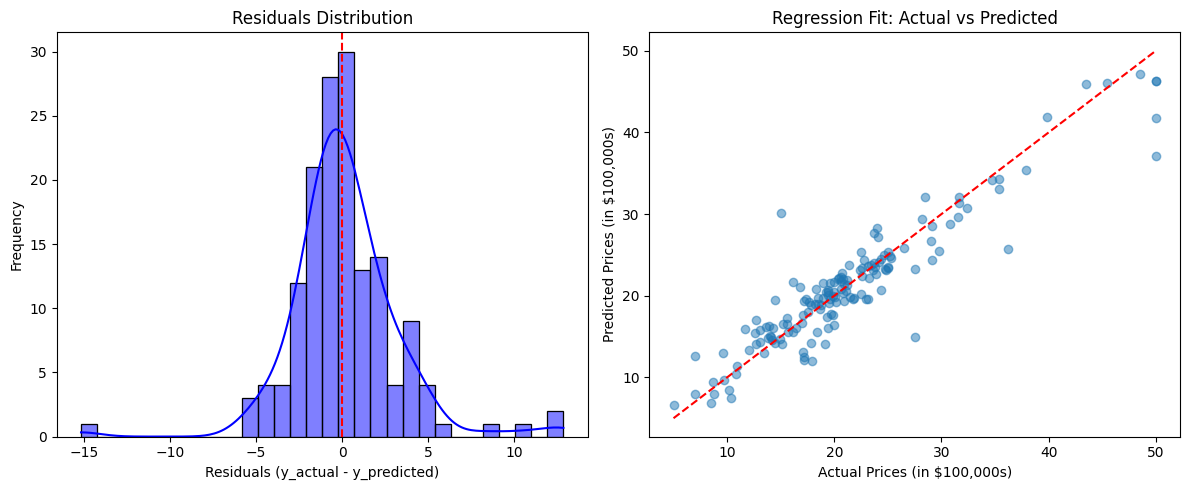

In [31]:
# Compute residuals.
residuals = ytest - rf_pred

# Create plots.
plt.figure(figsize=(12,5))

# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")

# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)
plt.scatter(ytest, rf_pred, alpha=0.5)
plt.plot([min(ytest), max(ytest)], [min(ytest), max(ytest)], color='red', linestyle='--')  # Perfect fit line
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Actual Prices (in $100,000s)")
plt.ylabel("Predicted Prices (in $100,000s)")

# Show plots.
plt.tight_layout()
plt.show()

In [32]:
feature_importances = pd.DataFrame({"feature":xtrain.columns,"importance":rf.feature_importances_}).sort_values(by="importance",ascending = False)
print("feature importances")
print(feature_importances)

feature importances
    feature  importance
4        RM    0.441824
10    LSTAT    0.382904
6       DIS    0.068170
0      CRIM    0.033653
9   PTRATIO    0.021340
5       AGE    0.013663
3       NOX    0.013291
8       TAX    0.011799
2     INDUS    0.007280
7       RAD    0.004515
1        ZN    0.001561


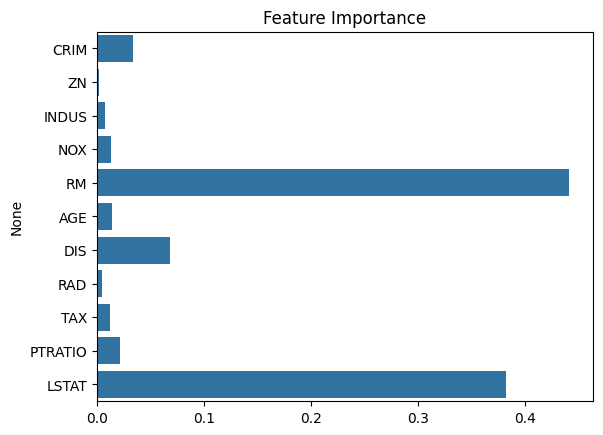

In [33]:
importances = rf.feature_importances_
features = xtrain.columns
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()


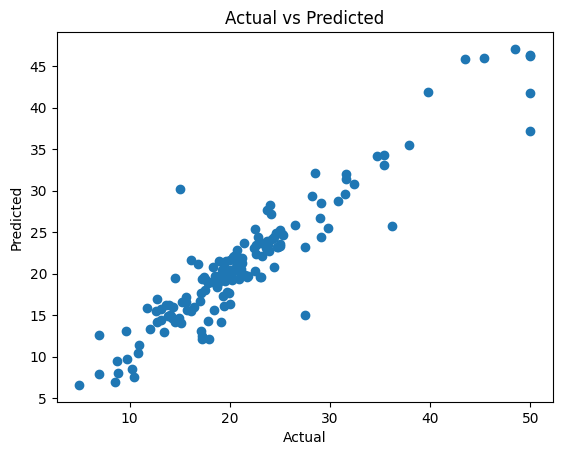

In [34]:
predictions = rf.predict(xtest)
plt.scatter(ytest, predictions)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


In [35]:
import joblib
# Save the model to a file
joblib.dump(rf,'boston_rf.pkl') # Saves the model as 'boston_rf.pkl'


['boston_rf.pkl']

In [36]:
fd = df.to_csv(r"C:\Users\UZO\Documents\python_class\fd.csv")

In [37]:
# Create plots.
residual_df = pd.DataFrame({'Predicted Values': rf_pred, 'Residuals': residuals})

# Plot 1: Residuals Distribution.
fig = px.scatter(residual_df, x='Predicted Values', y='Residuals', 
                 title='Residual Plot for Random Forest Regression',
                 labels={'Predicted Values': 'Predicted Values', 'Residuals': 'Residuals'})
# Add a horizontal line at y=0 (ideal residual value)
fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Zero Residual Line", annotation_position="bottom right")

# Customize the plot
fig.update_layout(xaxis_title="Predicted Values", 
                  yaxis_title="Residuals (Actual - Predicted)")

# Show the plot
fig.show()

In [40]:
import plotly.graph_objects as go
df = pd.DataFrame({'Actual': ytest, 'Predicted': rf_pred})

# Create scatter plot of Actual vs Predicted
fig = px.scatter(df, x='Actual', y='Predicted', 
                 title='Actual vs. Predicted Values',
                 labels={'Actual': 'Actual Value', 'Predicted': 'Predicted Value'})

#Add diagonal line for perfect prediction reference
min_val = min(df['Actual'].min(), df['Predicted'].min())
max_val = max(df['Actual'].max(), df['Predicted'].max())
fig.add_shape(type="line", x0=min_val, y0=min_val, x1=max_val, y1=max_val,
              line=dict(color="Red", dash="dash"))

fig.show()
